In [1]:
from pathlib import Path
PROJECT_FOLDER = Path.cwd().parents[1]

import yaml
with open('config.yaml', 'r', encoding='utf-8') as f: 
    config = yaml.safe_load(f)

import sys, os
sys.path.append(PROJECT_FOLDER)
os.chdir(PROJECT_FOLDER)

print(sys.path[-1])
print(config)

/Users/sam/NUS/NUSC-ISC-FootballAnalysis
{'experiment_name': 'ex03_gaussian_heatmap', 'pitch_calibration_dataset': {'img_folder': 'data/calibration', 'width': 640, 'height': 360, 'centered': False, 'keypoint_only': False, 'selected_idxs': [0, 3, 4, 5]}, 'pitch_calibration_datamodule': {'batch_size': 8, 'num_workers': 8, 'persistent_workers': True}, 'gaussian_heatmap_model': 'wandb_logs/ISC-Football/gwqhfk3g/checkpoints/epoch=2-step=192.ckpt', 'spiideo_dataset': {'base_folder': 'data/SpiideoSynLoc', 'width': 3840, 'height': 2160, 'n_crops': 16, 'crop_width': 512, 'crop_height': 512, 'n_limit': 4}, 'spiideo_datamodule': {'batch_size': 4, 'num_workers': 8, 'persistent_workers': True}, 'trainer': {'accelerator': 'gpu', 'max_epochs': 32}}


In [54]:
import cv2
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from losses.focal_loss import FocalLoss

In [19]:
%reload_ext autoreload
%autoreload 2

torch.Size([1, 1, 360, 640])


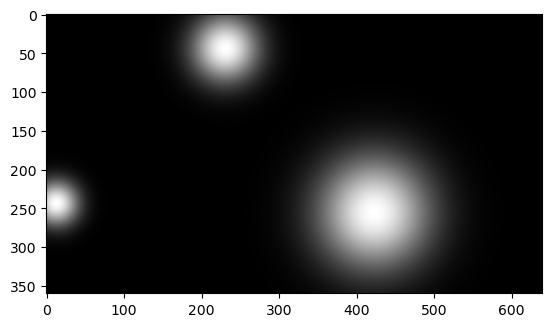

In [4]:
def generate_gmm_heatmap(shape, centers, sigmas):
    """
    Generates a 2D Gaussian Mixture Map.
    
    Args:
        shape: Tuple (height, width) for the output map.
        centers: List of tuples [(x1, y1), (x2, y2), ...]
        sigmas: List of sigmas. Can be a single value [s1, s2] 
                or tuples for anisotropic shapes [(sx1, sy1), ...].
    """
    h, w = shape
    # Create coordinate grids
    y_grid, x_grid = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')
    
    # Initialize an empty heatmap
    heatmap = np.zeros((h, w), dtype=np.float32)
    
    for (cx, cy), s in zip(centers, sigmas):
        # Handle both circular (scalar) and elliptical (tuple) sigmas
        sx, sy = (s, s) if isinstance(s, (int, float)) else s
        
        # Calculate the 2D Gaussian exponent
        exponent = -((x_grid - cx)**2 / (2 * sx**2) + (y_grid - cy)**2 / (2 * sy**2))
        
        # Add the Gaussian to the mixture
        heatmap += np.exp(exponent)
        
    return heatmap

centers = [(423, 256), (13, 244), (231, 45)]
sigmas = [50, 20, 30]
mask = generate_gmm_heatmap((360, 640), centers, sigmas)
mask = torch.tensor(mask).unsqueeze(0).unsqueeze(0)
print(mask.shape)
plt.imshow(mask[0][0], cmap='gray')
plt.show()

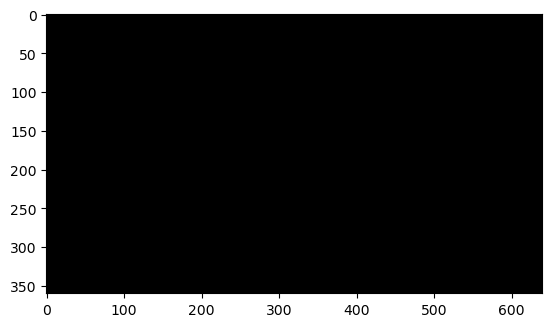

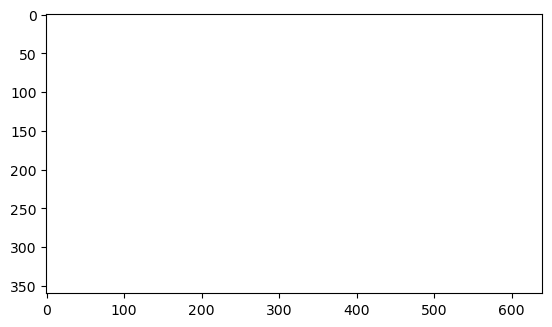

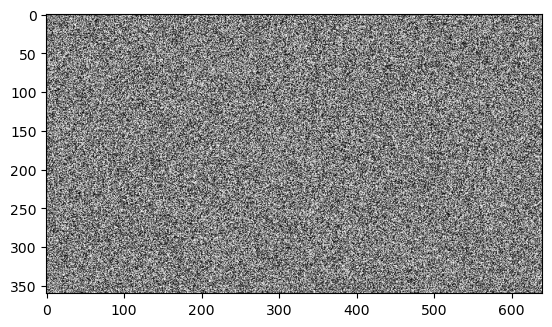

In [18]:
mask_0 = torch.zeros_like(mask).float()
mask_1 = torch.ones_like(mask).float()
mask_r = torch.rand_like(mask).float()

plt.imshow(mask_0[0][0], cmap='gray', vmin=0, vmax=1)
plt.show()

plt.imshow(mask_1[0][0], cmap='gray', vmin=0, vmax=1)
plt.show()

plt.imshow(mask_r[0][0], cmap='gray', vmin=0, vmax=1)
plt.show()

In [95]:
loss_fn = FocalLoss(alpha=0.99, gamma=0.05)
loss_0 = loss_fn(torch.zeros_like(mask), mask)
loss_r = loss_fn(torch.rand_like(mask), mask)
loss_1 = loss_fn(torch.ones_like(mask), mask)
loss_0, loss_r, loss_1

(tensor(0.3351), tensor(0.0518), tensor(0.0312))

In [99]:
loss_fn = FocalLoss(alpha=0.90, gamma=1e-4)

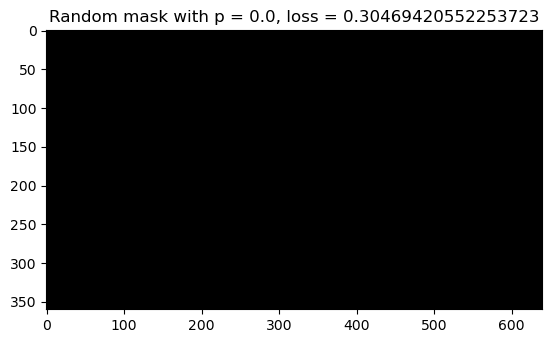

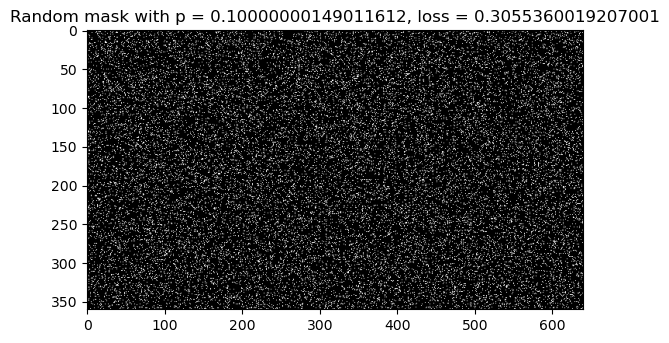

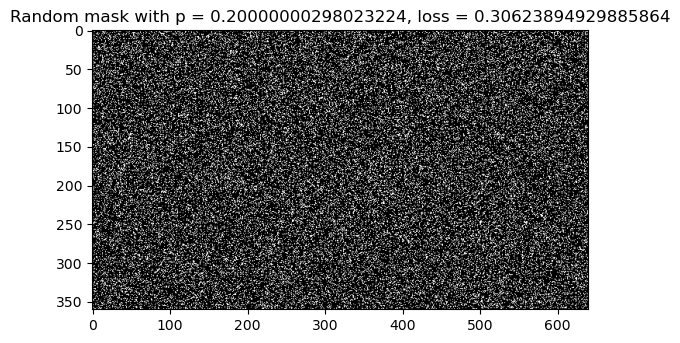

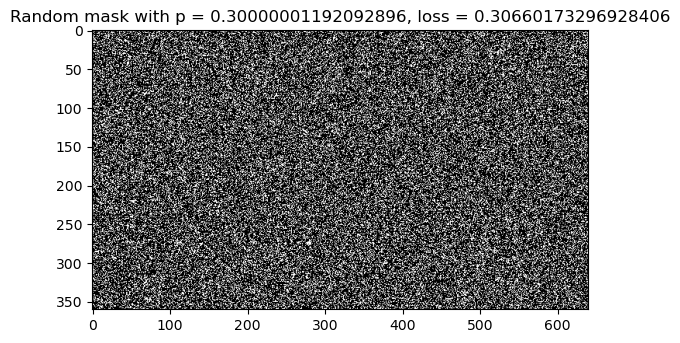

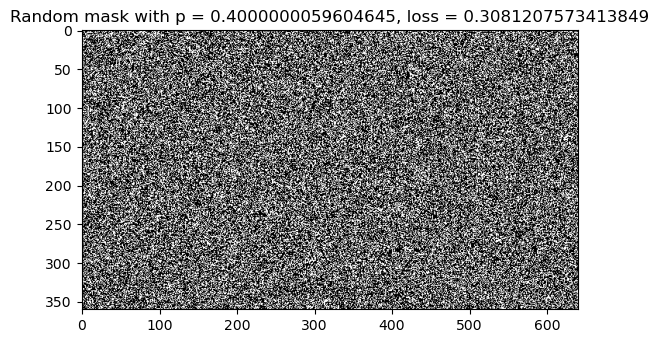

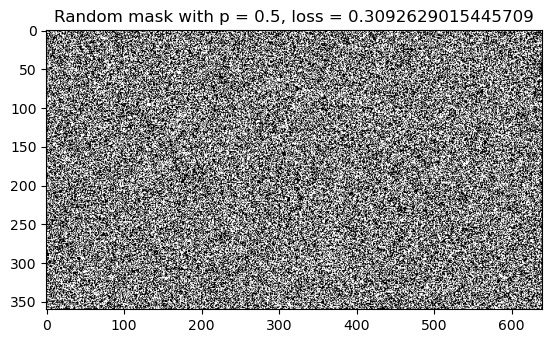

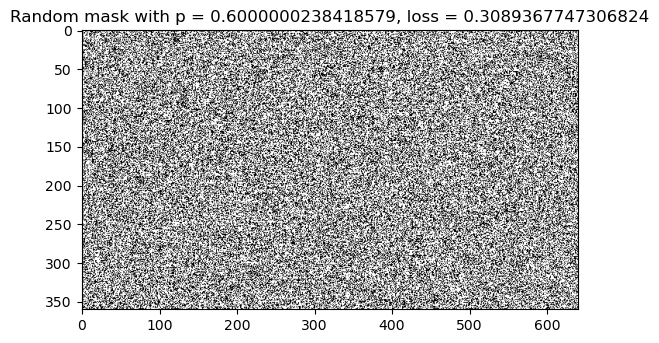

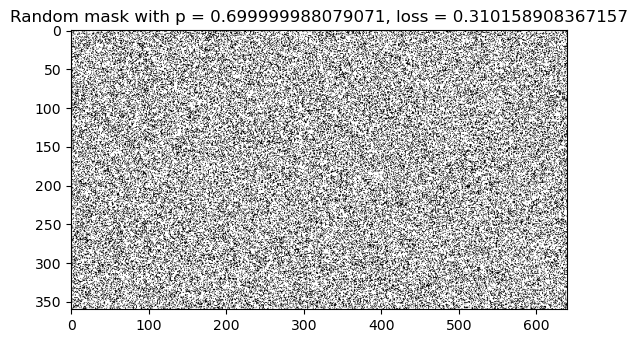

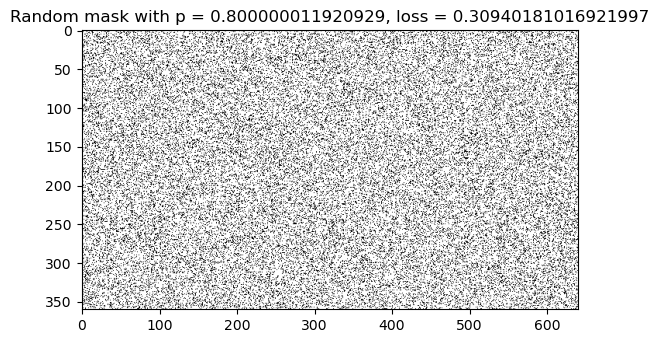

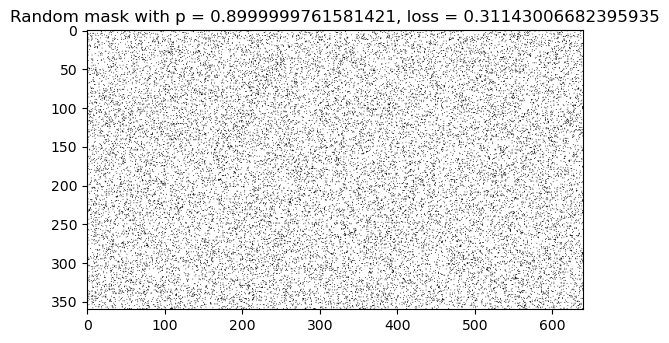

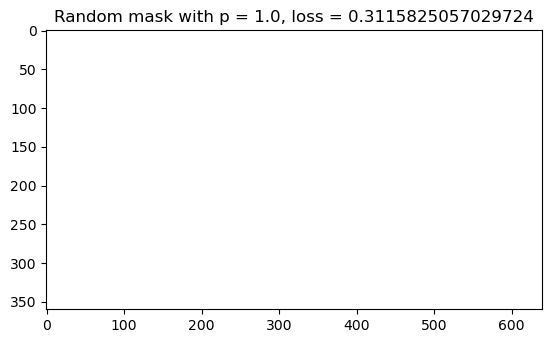

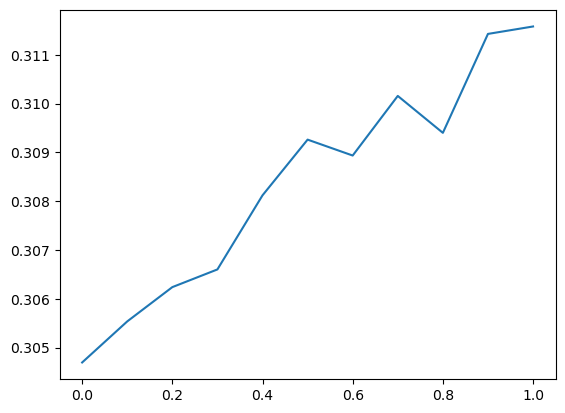

In [100]:
ps = torch.arange(0, 1.01, 0.1)
losses = []

for p in ps:
    pred = torch.distributions.Bernoulli(p).sample(mask.size())
    loss = loss_fn(pred, mask)
    losses.append(loss)

    plt.imshow(pred[0][0], cmap='gray', vmin=0, vmax=1)
    plt.title(f'Random mask with p = {p}, loss = {loss}')
    plt.show()

plt.plot(ps, losses)
plt.show()

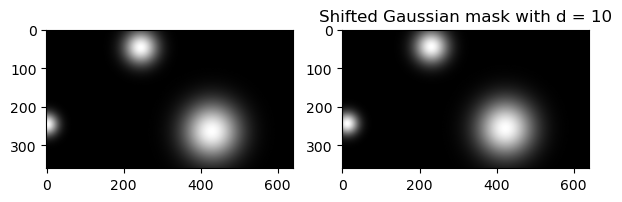

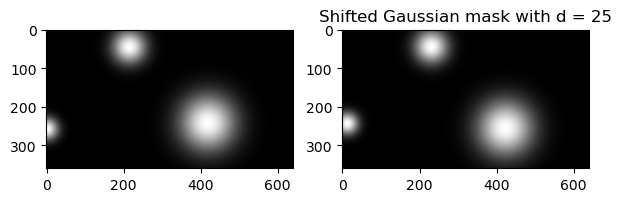

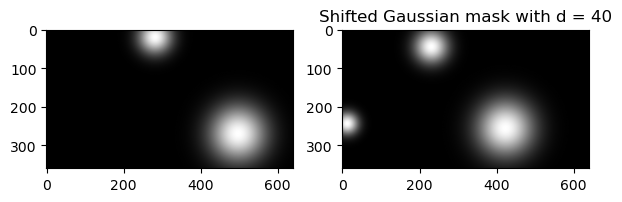

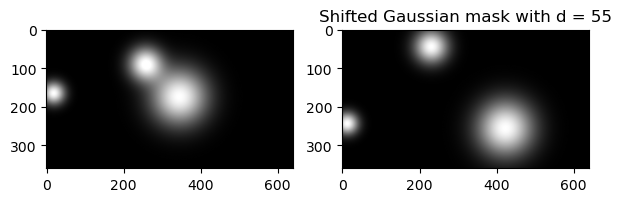

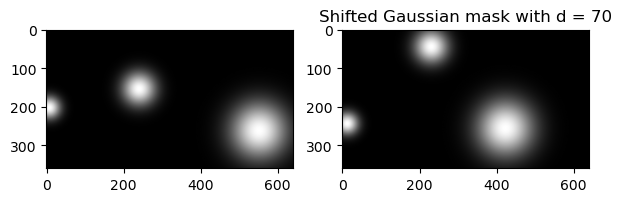

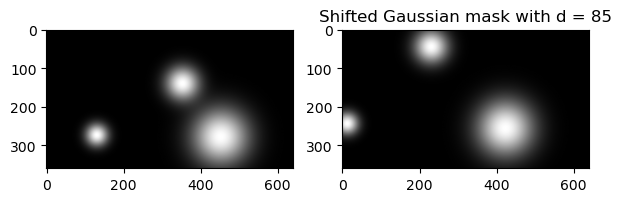

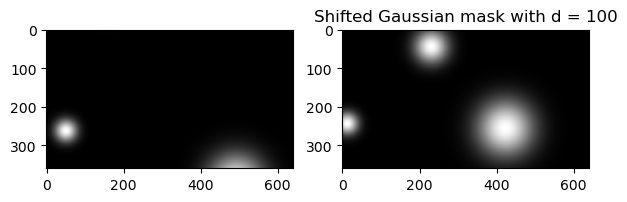

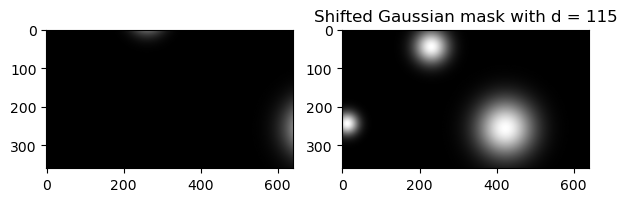

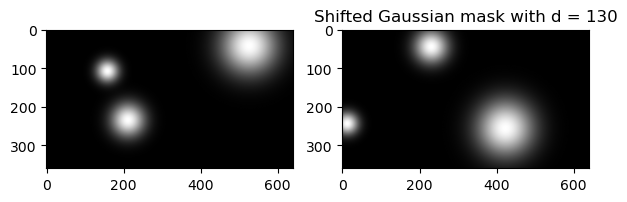

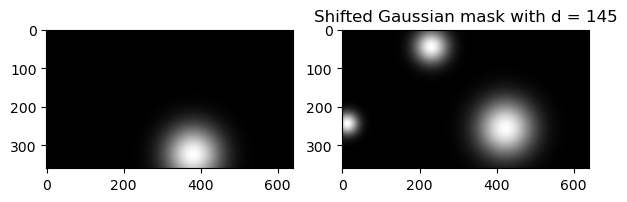

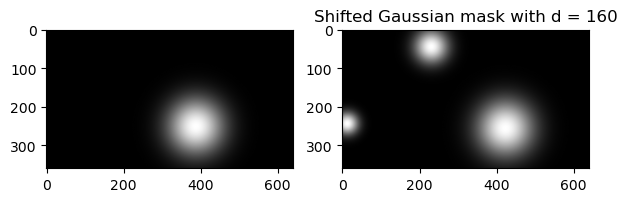

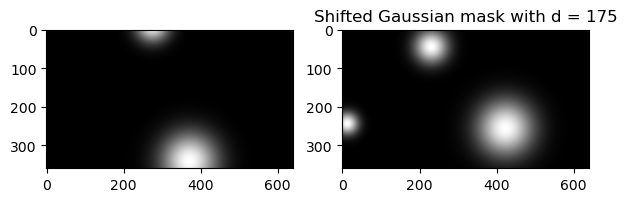

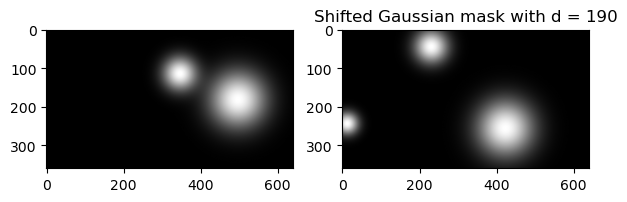

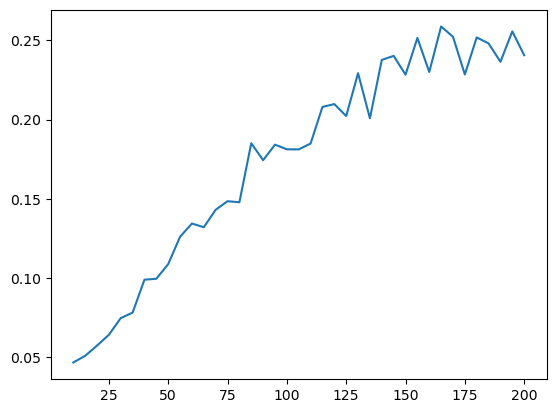

In [101]:
ds = torch.arange(10, 201, 5)
losses = []

for bdx, d in enumerate(ds):
    losses_d = []

    for idx in range(20):
        pred = torch.distributions.Bernoulli(p).sample(mask.size())

        centers_moved = []
        for cx, cy in centers:
            new_cx, new_cy = torch.distributions \
                .MultivariateNormal(
                    torch.tensor((cx, cy)).float(),
                    d * d * torch.eye(2)
                ) \
                .sample().tolist()

            centers_moved.append((new_cx, new_cy))

        pred = generate_gmm_heatmap(mask[0][0].shape, centers_moved, sigmas)
        pred = torch.tensor(pred).unsqueeze(0).unsqueeze(0)
        loss = loss_fn(pred, mask)
        losses_d.append(loss)

        if bdx % 3 == 0 and idx == 0:
            fig, axes = plt.subplots(ncols=2, figsize=(7, 4))
            axes[0].imshow(pred[0][0], cmap='gray', vmin=0, vmax=1)
            axes[1].imshow(mask[0][0], cmap='gray', vmin=0, vmax=1)
            plt.title(f'Shifted Gaussian mask with d = {d}')
            plt.show()

    losses.append(torch.tensor(losses_d).mean())

plt.plot(ds, losses)
plt.show()